# CerchieSeasonality.ipynb | The Calendar of Risk

Question: **Does seasonality differ by Milan city ring in amplitude, phase, or both?**

This notebook uses the cleaned monthly city-ring crash panel. It is inference-first: the descriptive plots show the shape, then the Poisson and robustness models test whether ring changes the seasonal pattern rather than only the average crash level. No analysis outputs are written to disk.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

SEED = 42
rng = np.random.default_rng(SEED)

pd.options.display.max_columns = 200
pd.options.display.float_format = "{:.4f}".format


def resolve_project_root() -> Path:
    for root in [Path.cwd(), *Path.cwd().parents]:
        if (root / "pyproject.toml").exists() and (root / "data" / "processed").exists():
            return root
    raise FileNotFoundError("Could not resolve project root containing pyproject.toml and data/processed.")


def pick_column(frame: pd.DataFrame, candidates: list[str], role: str) -> str:
    lookup = {col.lower(): col for col in frame.columns}
    for candidate in candidates:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]
    raise KeyError(f"Could not find {role}. Tried: {candidates}. Available: {list(frame.columns)}")


project_root = resolve_project_root()
processed_dir = project_root / "data" / "processed"
input_path = processed_dir / "milan_crashes_monthly_city_ring_cleaned.csv"

if not input_path.exists():
    raise FileNotFoundError(
        f"Required input is missing: {input_path}. Run the Milan crash cleaning notebook first."
    )

raw_ring_panel = pd.read_csv(input_path)

outcome_col = pick_column(raw_ring_panel, ["Incidenti", "incidents", "crashes", "total_incidents"], "crash-count outcome")
ring_col = pick_column(raw_ring_panel, ["Cerchia", "city_ring", "ring"], "city-ring column")
year_col = pick_column(raw_ring_panel, ["Anno", "Year", "year"], "year column")
month_col = pick_column(raw_ring_panel, ["Mese", "month", "Month"], "month column")

area_by_cerchia = pd.DataFrame(
    [
        {"Cerchia": "Entro la Cerchia dei Navigli", "area_km2": 2.97, "area_note": "confirmed"},
        {"Cerchia": "Dalla Cerchia dei Navigli alle Mura Spagnole", "area_km2": 6.70, "area_note": "confirmed"},
        {"Cerchia": "Dalle Mura Spagnole alla Nuova Circonvallazione", "area_km2": 21.33, "area_note": "approximation"},
        {"Cerchia": "Dalla Nuova Circonvallazione ai confini del Comune", "area_km2": 150.84, "area_note": "approximation"},
    ]
)

ring_panel = raw_ring_panel.rename(
    columns={outcome_col: "crash_count", ring_col: "Cerchia", year_col: "Year", month_col: "month"}
).copy()
ring_panel["crash_count"] = pd.to_numeric(ring_panel["crash_count"], errors="raise")
ring_panel["Year"] = pd.to_numeric(ring_panel["Year"], errors="raise").astype(int)
ring_panel["month"] = pd.to_numeric(ring_panel["month"], errors="raise").astype(int)
ring_panel["Cerchia"] = ring_panel["Cerchia"].astype("string").str.strip()
ring_panel["month_start"] = pd.to_datetime(
    {"year": ring_panel["Year"], "month": ring_panel["month"], "day": 1},
    errors="raise",
)

invalid_months = sorted(set(ring_panel.loc[~ring_panel["month"].between(1, 12), "month"]))
if invalid_months:
    raise ValueError(f"Invalid month values found: {invalid_months}")
if ring_panel["crash_count"].isna().any() or (ring_panel["crash_count"] < 0).any():
    raise ValueError("Crash-count outcome has missing or negative values.")

ring_panel = ring_panel.merge(area_by_cerchia, on="Cerchia", how="left")
excluded_rings = sorted(ring_panel.loc[ring_panel["area_km2"].isna(), "Cerchia"].dropna().unique())
analysis_df = ring_panel.dropna(subset=["area_km2"]).copy()
if analysis_df.empty:
    raise ValueError("No area-normalized city rings remain after merging the area table.")

obs_by_ring = analysis_df.groupby("Cerchia").size().rename("monthly_observations").reset_index()
if (obs_by_ring["monthly_observations"] < 36).any():
    raise ValueError("At least one ring has fewer than 36 monthly observations; seasonality inference is unstable.")

validation_summary = pd.DataFrame(
    [
        {"check": "source file", "value": str(input_path.relative_to(project_root))},
        {"check": "raw rows", "value": len(raw_ring_panel)},
        {"check": "analysis rows with known area", "value": len(analysis_df)},
        {"check": "year range", "value": f"{analysis_df['Year'].min()}-{analysis_df['Year'].max()}"},
        {"check": "month coverage", "value": ", ".join(map(str, sorted(analysis_df["month"].unique())))},
        {"check": "outcome column", "value": outcome_col},
        {"check": "rings excluded from density models", "value": ", ".join(excluded_rings) if excluded_rings else "none"},
    ]
)

print(f"Loaded {len(raw_ring_panel):,} rows from {input_path.relative_to(project_root)}")
print(f"Using outcome column: {outcome_col!r} as monthly crash count")
print("Months are valid 1-12; each modeled ring has enough monthly observations.")
display(validation_summary)
display(obs_by_ring)
display(area_by_cerchia)


Loaded 1,440 rows from data/processed/milan_crashes_monthly_city_ring_cleaned.csv
Using outcome column: 'Incidenti' as monthly crash count
Months are valid 1-12; each modeled ring has enough monthly observations.


,check,value
0,source file,data/processed/milan_crashes_monthly_city_ring...
1,raw rows,1440
2,analysis rows with known area,1152
3,year range,2001-2024
4,month coverage,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12"
5,outcome column,Incidenti
6,rings excluded from density models,Senza indicazioni


,Cerchia,monthly_observations
0,Dalla Cerchia dei Navigli alle Mura Spagnole,288
1,Dalla Nuova Circonvallazione ai confini del Co...,288
2,Dalle Mura Spagnole alla Nuova Circonvallazione,288
3,Entro la Cerchia dei Navigli,288


,Cerchia,area_km2,area_note
0,Entro la Cerchia dei Navigli,2.9700,confirmed
1,Dalla Cerchia dei Navigli alle Mura Spagnole,6.7000,confirmed
2,Dalle Mura Spagnole alla Nuova Circonvallazione,21.3300,approximation
3,Dalla Nuova Circonvallazione ai confini del Co...,150.8400,approximation


### Interpretation: data loading and validation

This block answers whether the right unit of analysis is present: one row per ring and month with a valid crash-count outcome. The model excludes `Senza indicazioni` because it has no geographic area, so it cannot be used for per-km2 exposure normalization. The inference below is therefore about the four named Milan rings, not the unlocated residual category.


Ring x month table: mean monthly crash counts


month_label,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Cerchia,,,,,,,,,,,,
Dalla Cerchia dei Navigli alle Mura Spagnole,52.2100,49.5800,59.6200,55.5800,67.5800,62.4200,58.7900,22.0800,63.0800,71.0000,66.0000,53.6200
Dalla Nuova Circonvallazione ai confini del Comune,472.3800,452.5800,538.4200,538.5000,617.4200,616.4200,592.8800,330.2900,585.2900,639.7100,557.5000,469.8300
Dalle Mura Spagnole alla Nuova Circonvallazione,222.6700,225.4600,270.7900,259.4600,301.7900,294.1700,278.3300,137.2500,282.4600,323.0800,293.3800,233.3800
Entro la Cerchia dei Navigli,25.0800,22.5400,25.9600,25.8800,31.5800,27.8300,27.0400,12.3300,28.4600,34.6200,30.5400,25.5400


Ring x month table: mean monthly crash counts per km2


month_label,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Cerchia,,,,,,,,,,,,
Dalla Cerchia dei Navigli alle Mura Spagnole,7.7920,7.4000,8.8990,8.2960,10.0870,9.3160,8.7750,3.2960,9.4150,10.5970,9.8510,8.0040
Dalla Nuova Circonvallazione ai confini del Comune,3.1320,3.0000,3.5690,3.5700,4.0930,4.0870,3.9300,2.1900,3.8800,4.2410,3.6960,3.1150
Dalle Mura Spagnole alla Nuova Circonvallazione,10.4390,10.5700,12.6950,12.1640,14.1490,13.7910,13.0490,6.4350,13.2420,15.1470,13.7540,10.9410
Entro la Cerchia dei Navigli,8.4460,7.5900,8.7400,8.7120,10.6340,9.3710,9.1050,4.1530,9.5820,11.6580,10.2830,8.6000


Peak/trough seasonality metrics by ring


,Cerchia,mean_monthly_crashes,mean_monthly_crashes_per_km2,peak_month,trough_month,peak_trough_ratio,absolute_amplitude,relative_amplitude
1,Dalla Nuova Circonvallazione ai confini del Co...,534.2674,3.5419,Oct,Aug,1.9368,309.4167,0.5791
2,Dalle Mura Spagnole alla Nuova Circonvallazione,260.1840,12.1980,Oct,Aug,2.3540,185.8333,0.7142
0,Dalla Cerchia dei Navigli alle Mura Spagnole,56.7986,8.4774,Oct,Aug,3.2151,48.9167,0.8612
3,Entro la Cerchia dei Navigli,26.4514,8.9062,Oct,Aug,2.8074,22.2917,0.8427


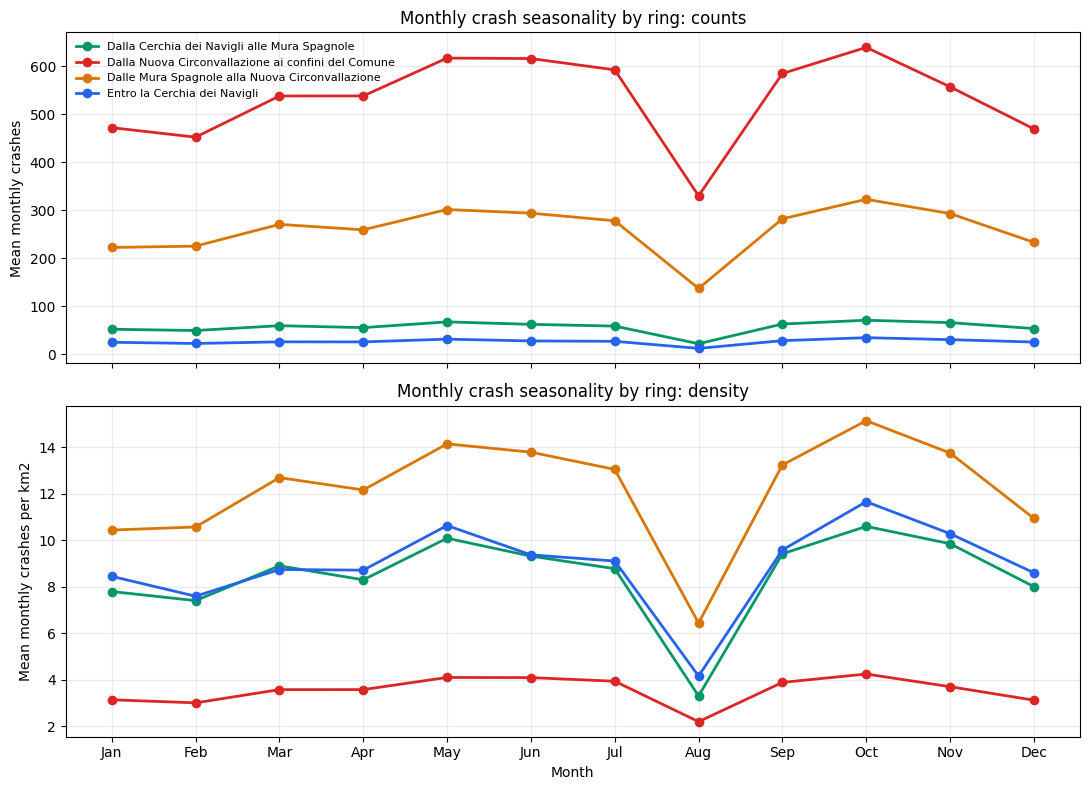

In [2]:
month_labels = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}
month_order = list(range(1, 13))

monthly_profiles = (
    analysis_df.groupby(["Cerchia", "month"], as_index=False)
    .agg(
        mean_monthly_crashes=("crash_count", "mean"),
        area_km2=("area_km2", "first"),
    )
    .sort_values(["Cerchia", "month"])
)
monthly_profiles["mean_monthly_crashes_per_km2"] = (
    monthly_profiles["mean_monthly_crashes"] / monthly_profiles["area_km2"]
)
monthly_profiles["month_label"] = monthly_profiles["month"].map(month_labels)

ring_month_counts = (
    monthly_profiles.pivot(index="Cerchia", columns="month_label", values="mean_monthly_crashes")
    .reindex(columns=[month_labels[m] for m in month_order])
    .round(2)
)
ring_month_rates = (
    monthly_profiles.pivot(index="Cerchia", columns="month_label", values="mean_monthly_crashes_per_km2")
    .reindex(columns=[month_labels[m] for m in month_order])
    .round(3)
)

def descriptive_row(group: pd.DataFrame) -> pd.Series:
    peak = group.loc[group["mean_monthly_crashes"].idxmax()]
    trough = group.loc[group["mean_monthly_crashes"].idxmin()]
    mean_count = group["mean_monthly_crashes"].mean()
    absolute_amplitude = peak["mean_monthly_crashes"] - trough["mean_monthly_crashes"]
    return pd.Series(
        {
            "mean_monthly_crashes": mean_count,
            "mean_monthly_crashes_per_km2": group["mean_monthly_crashes_per_km2"].mean(),
            "peak_month": month_labels[int(peak["month"])],
            "trough_month": month_labels[int(trough["month"])],
            "peak_trough_ratio": peak["mean_monthly_crashes"] / trough["mean_monthly_crashes"],
            "absolute_amplitude": absolute_amplitude,
            "relative_amplitude": absolute_amplitude / mean_count,
        }
    )

descriptive_stats = (
    monthly_profiles.groupby("Cerchia", group_keys=False)
    .apply(descriptive_row, include_groups=False)
    .reset_index()
    .sort_values("absolute_amplitude", ascending=False)
)

print("Ring x month table: mean monthly crash counts")
display(ring_month_counts)
print("Ring x month table: mean monthly crash counts per km2")
display(ring_month_rates)
print("Peak/trough seasonality metrics by ring")
display(descriptive_stats.round(4))

palette = {
    "Entro la Cerchia dei Navigli": "#2563eb",
    "Dalla Cerchia dei Navigli alle Mura Spagnole": "#059669",
    "Dalle Mura Spagnole alla Nuova Circonvallazione": "#d97706",
    "Dalla Nuova Circonvallazione ai confini del Comune": "#dc2626",
}

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for ring, group in monthly_profiles.groupby("Cerchia"):
    color = palette.get(ring)
    axes[0].plot(group["month"], group["mean_monthly_crashes"], marker="o", linewidth=2, label=ring, color=color)
    axes[1].plot(group["month"], group["mean_monthly_crashes_per_km2"], marker="o", linewidth=2, label=ring, color=color)

axes[0].set_title("Monthly crash seasonality by ring: counts")
axes[0].set_ylabel("Mean monthly crashes")
axes[0].grid(alpha=0.25)
axes[1].set_title("Monthly crash seasonality by ring: density")
axes[1].set_ylabel("Mean monthly crashes per km2")
axes[1].set_xlabel("Month")
axes[1].set_xticks(month_order)
axes[1].set_xticklabels([month_labels[m] for m in month_order])
axes[1].grid(alpha=0.25)
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()


### Interpretation: descriptive seasonality

This block answers the first plain-language version of the question: which rings have the largest seasonal swing and when do they peak? The count curves show operational workload, while the per-km2 curves show geographic pressure. These are descriptive averages, so they do not yet prove that ring changes the seasonal pattern after year effects are controlled.


In [3]:
model_df = analysis_df.copy()
model_df["log_area_km2"] = np.log(model_df["area_km2"])
for period in [12, 6]:
    model_df[f"sin{period}"] = np.sin(2 * np.pi * model_df["month"] / period)
    model_df[f"cos{period}"] = np.cos(2 * np.pi * model_df["month"] / period)

reference_ring = "Entro la Cerchia dei Navigli"
ring_term = f"C(Cerchia, Treatment(reference={reference_ring!r}))"
harmonic_terms = "sin12 + cos12 + sin6 + cos6"
year_term = "C(Year)"

reduced_formula = f"crash_count ~ {ring_term} + {year_term} + {harmonic_terms}"
full_formula = f"crash_count ~ {ring_term} + {year_term} + {harmonic_terms} + {ring_term}:({harmonic_terms})"

reduced_poisson = smf.glm(
    reduced_formula,
    data=model_df,
    family=sm.families.Poisson(),
    offset=model_df["log_area_km2"],
).fit()
full_poisson = smf.glm(
    full_formula,
    data=model_df,
    family=sm.families.Poisson(),
    offset=model_df["log_area_km2"],
).fit()
full_poisson_robust = smf.glm(
    full_formula,
    data=model_df,
    family=sm.families.Poisson(),
    offset=model_df["log_area_km2"],
).fit(cov_type="HC0")

interaction_terms = [
    name
    for name in full_poisson_robust.params.index
    if (":sin" in name or ":cos" in name) and "Cerchia" in name
]
constraint = np.zeros((len(interaction_terms), len(full_poisson_robust.params)))
for row_idx, term in enumerate(interaction_terms):
    constraint[row_idx, list(full_poisson_robust.params.index).index(term)] = 1
wald_result = full_poisson_robust.wald_test(constraint, scalar=True)

harmonic_lr_stat = 2 * (full_poisson.llf - reduced_poisson.llf)
harmonic_lr_df = int(full_poisson.df_model - reduced_poisson.df_model)
harmonic_lr_p = stats.chi2.sf(harmonic_lr_stat, harmonic_lr_df)
harmonic_overdispersion = full_poisson.pearson_chi2 / full_poisson.df_resid

month_reduced_formula = f"crash_count ~ {ring_term} + {year_term} + C(month)"
month_full_formula = f"crash_count ~ {ring_term} * C(month) + {year_term}"
month_reduced = smf.glm(
    month_reduced_formula,
    data=model_df,
    family=sm.families.Poisson(),
    offset=model_df["log_area_km2"],
).fit()
month_full = smf.glm(
    month_full_formula,
    data=model_df,
    family=sm.families.Poisson(),
    offset=model_df["log_area_km2"],
).fit()
month_lr_stat = 2 * (month_full.llf - month_reduced.llf)
month_lr_df = int(month_full.df_model - month_reduced.df_model)
month_lr_p = stats.chi2.sf(month_lr_stat, month_lr_df)
month_overdispersion = month_full.pearson_chi2 / month_full.df_resid

nb_lr_stat = np.nan
nb_lr_df = np.nan
nb_lr_p = np.nan
nb_alpha = np.nan
nb_note = "not run"
if harmonic_overdispersion > 2:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            nb_reduced = smf.negativebinomial(
                reduced_formula,
                data=model_df,
                offset=model_df["log_area_km2"],
            ).fit(disp=False, maxiter=300)
            nb_full = smf.negativebinomial(
                full_formula,
                data=model_df,
                offset=model_df["log_area_km2"],
            ).fit(disp=False, maxiter=300)
        nb_lr_stat = 2 * (nb_full.llf - nb_reduced.llf)
        nb_lr_df = int(nb_full.df_model - nb_reduced.df_model)
        nb_lr_p = stats.chi2.sf(nb_lr_stat, nb_lr_df)
        nb_alpha = nb_full.params.get("alpha", np.nan)
        nb_note = "negative binomial check completed"
    except Exception as exc:
        nb_note = f"negative binomial check failed: {exc}"

model_tests = pd.DataFrame(
    [
        {
            "test": "Harmonic Poisson LRT: ring x seasonality",
            "statistic": harmonic_lr_stat,
            "df": harmonic_lr_df,
            "p_value": harmonic_lr_p,
            "overdispersion": harmonic_overdispersion,
            "note": "offset log(area_km2); year fixed effects",
        },
        {
            "test": "Harmonic Poisson robust Wald: ring x seasonality",
            "statistic": float(wald_result.statistic),
            "df": float(wald_result.df_denom),
            "p_value": float(wald_result.pvalue),
            "overdispersion": harmonic_overdispersion,
            "note": "HC0 covariance; same full harmonic model",
        },
        {
            "test": "Month fixed-effects Poisson LRT: ring x month",
            "statistic": month_lr_stat,
            "df": month_lr_df,
            "p_value": month_lr_p,
            "overdispersion": month_overdispersion,
            "note": "flexible month effects; offset log(area_km2)",
        },
        {
            "test": "Negative binomial LRT: ring x seasonality",
            "statistic": nb_lr_stat,
            "df": nb_lr_df,
            "p_value": nb_lr_p,
            "overdispersion": np.nan,
            "note": f"{nb_note}; alpha={nb_alpha:.4f}" if pd.notna(nb_alpha) else nb_note,
        },
    ]
)

print("Model outcome: monthly crash count")
print("Exposure handling: offset log(area_km2), so coefficients compare crash density rather than raw area size.")
print("Core H0: all ring x seasonal harmonic interaction coefficients are zero.")
display(model_tests)


Model outcome: monthly crash count
Exposure handling: offset log(area_km2), so coefficients compare crash density rather than raw area size.
Core H0: all ring x seasonal harmonic interaction coefficients are zero.


,test,statistic,df,p_value,overdispersion,note
0,Harmonic Poisson LRT: ring x seasonality,155.2238,12.0000,0.0000,7.4333,offset log(area_km2); year fixed effects
1,Harmonic Poisson robust Wald: ring x seasonality,20.7045,12.0000,0.0549,7.4333,HC0 covariance; same full harmonic model
2,Month fixed-effects Poisson LRT: ring x month,281.8357,33.0000,0.0000,3.6486,flexible month effects; offset log(area_km2)
3,Negative binomial LRT: ring x seasonality,20.5324,12.0000,0.0577,NaN,negative binomial check completed; alpha=0.0435


### Interpretation: inferential model

The harmonic model asks whether rings differ in a smooth annual or semi-annual seasonal shape after controlling for year and average ring level. The likelihood-ratio test rejects that no-interaction model, but overdispersion is large, so the robust Wald and negative-binomial checks are the more conservative harmonic evidence. The month fixed-effects model is less smooth and asks the same question more flexibly: does the ring-by-month table matter after year and ring controls? That robustness check is strongly significant.


In [4]:
def interaction_name(params: pd.Series, ring: str, harmonic: str) -> str | None:
    if ring == reference_ring:
        return None
    for name in params.index:
        if f"[T.{ring}]" in name and f":{harmonic}" in name:
            return name
    return None


def ring_harmonic_coefficients(params: pd.Series, ring: str) -> dict[str, float]:
    values = {}
    for harmonic in ["sin12", "cos12", "sin6", "cos6"]:
        value = float(params.get(harmonic, 0.0))
        extra_name = interaction_name(params, ring, harmonic)
        if extra_name is not None:
            value += float(params.get(extra_name, 0.0))
        values[harmonic] = value
    return values


def continuous_peak_month(sin_coef: float, cos_coef: float, period: int) -> float:
    angle = np.arctan2(sin_coef, cos_coef)
    if angle <= 0:
        angle += 2 * np.pi
    month = angle * period / (2 * np.pi)
    return period if np.isclose(month, 0) else month


def nearest_month_label(month_value: float, period: int = 12) -> str:
    month = int(np.round(month_value))
    if month <= 0:
        month += period
    while month > period:
        month -= period
    return month_labels[month]


def nearest_month_number(month_value: float, period: int = 12) -> int:
    month = int(np.round(month_value))
    if month <= 0:
        month += period
    while month > period:
        month -= period
    return month


def harmonic_quantities(params: pd.Series, ring: str) -> dict[str, float | str]:
    coefs = ring_harmonic_coefficients(params, ring)
    annual_amplitude = float(np.hypot(coefs["sin12"], coefs["cos12"]))
    annual_peak = continuous_peak_month(coefs["sin12"], coefs["cos12"], 12)
    semi_amplitude = float(np.hypot(coefs["sin6"], coefs["cos6"]))
    semi_peak = continuous_peak_month(coefs["sin6"], coefs["cos6"], 6)
    semi_peak_1 = nearest_month_number(semi_peak, 6)
    semi_peak_2 = semi_peak_1 + 6
    return {
        "annual_amplitude_log_rate": annual_amplitude,
        "annual_peak_continuous_month": annual_peak,
        "annual_peak_month": nearest_month_label(annual_peak, 12),
        "semiannual_amplitude_log_rate": semi_amplitude,
        "semiannual_peak_months": f"{month_labels[semi_peak_1]} / {month_labels[semi_peak_2]}",
    }


def sample_parameters(params: pd.Series, cov: pd.DataFrame, draws: int = 800) -> pd.DataFrame:
    cov_matrix = np.asarray(cov, dtype=float)
    cov_matrix = (cov_matrix + cov_matrix.T) / 2
    eigvals, eigvecs = np.linalg.eigh(cov_matrix)
    eigvals = np.clip(eigvals, 1e-12, None)
    transform = eigvecs @ np.diag(np.sqrt(eigvals))
    normal_draws = rng.standard_normal((draws, len(params)))
    sampled = np.asarray(params) + normal_draws @ transform.T
    return pd.DataFrame(sampled, columns=params.index)


def circular_ci(samples: np.ndarray, center: float, period: int) -> tuple[float, float]:
    offsets = ((samples - center + period / 2) % period) - period / 2
    low, high = np.percentile(offsets, [2.5, 97.5])
    return (center + low - 1) % period + 1, (center + high - 1) % period + 1

param_draws = sample_parameters(full_poisson_robust.params, full_poisson_robust.cov_params(), draws=800)
harmonic_rows = []
bootstrap_rows = []
for ring in sorted(model_df["Cerchia"].unique()):
    point = harmonic_quantities(full_poisson_robust.params, ring)
    harmonic_rows.append({"Cerchia": ring, **point})

    draw_metrics = [harmonic_quantities(draw, ring) for _, draw in param_draws.iterrows()]
    draw_frame = pd.DataFrame(draw_metrics)
    annual_peak_ci = circular_ci(
        draw_frame["annual_peak_continuous_month"].to_numpy(dtype=float),
        float(point["annual_peak_continuous_month"]),
        12,
    )
    bootstrap_rows.append(
        {
            "Cerchia": ring,
            "annual_amplitude_ci_low": np.percentile(draw_frame["annual_amplitude_log_rate"], 2.5),
            "annual_amplitude_ci_high": np.percentile(draw_frame["annual_amplitude_log_rate"], 97.5),
            "annual_peak_ci_low_month": annual_peak_ci[0],
            "annual_peak_ci_high_month": annual_peak_ci[1],
            "semiannual_amplitude_ci_low": np.percentile(draw_frame["semiannual_amplitude_log_rate"], 2.5),
            "semiannual_amplitude_ci_high": np.percentile(draw_frame["semiannual_amplitude_log_rate"], 97.5),
        }
    )

harmonic_table = pd.DataFrame(harmonic_rows).merge(pd.DataFrame(bootstrap_rows), on="Cerchia")

print("Harmonic amplitude and phase estimates from the full Poisson model with robust covariance bootstrap")
display(harmonic_table.round(4))


Harmonic amplitude and phase estimates from the full Poisson model with robust covariance bootstrap


,Cerchia,annual_amplitude_log_rate,annual_peak_continuous_month,annual_peak_month,semiannual_amplitude_log_rate,semiannual_peak_months,annual_amplitude_ci_low,annual_amplitude_ci_high,annual_peak_ci_low_month,annual_peak_ci_high_month,semiannual_amplitude_ci_low,semiannual_amplitude_ci_high
0,Dalla Cerchia dei Navigli alle Mura Spagnole,0.0233,1.3731,Jan,0.2040,May / Nov,0.0065,0.0733,8.1763,6.8198,0.1607,0.2529
1,Dalla Nuova Circonvallazione ai confini del Co...,0.0645,6.6927,Jul,0.1409,May / Nov,0.0381,0.0970,5.8522,7.3697,0.1138,0.1681
2,Dalle Mura Spagnole alla Nuova Circonvallazione,0.0288,6.7808,Jul,0.1779,May / Nov,0.0061,0.0647,3.6606,8.7766,0.1490,0.2117
3,Entro la Cerchia dei Navigli,0.0286,11.4421,Nov,0.2023,May / Nov,0.0077,0.0816,7.8609,2.4225,0.1519,0.2548


### Interpretation: amplitude and phase

Harmonic coefficients are not intuitive on their own, so this block converts them into amplitude and peak timing. Annual amplitude is the size of the once-per-year swing on the log-rate scale. Peak month is estimated from the annual sine/cosine pair; when the confidence interval is wide, the exact annual phase should be treated cautiously. The semi-annual pair captures two high points per year, which is useful here because the descriptive curves have a strong spring/autumn structure.


In [5]:
p_value_label = f"Poisson LRT p={harmonic_lr_p:.2e}; robust Wald p={float(wald_result.pvalue):.3f}; NB p={nb_lr_p:.3f}; month-FE p={month_lr_p:.2e}"

final_table = (
    descriptive_stats.merge(harmonic_table, on="Cerchia")
    .sort_values("absolute_amplitude", ascending=False)
    .reset_index(drop=True)
)
final_table["global_interaction_test"] = p_value_label
final_table["short_interpretation"] = final_table.apply(
    lambda row: (
        "largest absolute seasonal swing" if row.name == 0 else
        "high relative swing" if row["relative_amplitude"] >= 0.8 else
        "same October trough/peak pattern, smaller relative swing"
    ),
    axis=1,
)

presentation_table = final_table[
    [
        "Cerchia",
        "mean_monthly_crashes",
        "mean_monthly_crashes_per_km2",
        "peak_month",
        "trough_month",
        "peak_trough_ratio",
        "absolute_amplitude",
        "relative_amplitude",
        "annual_amplitude_log_rate",
        "annual_peak_month",
        "semiannual_amplitude_log_rate",
        "semiannual_peak_months",
        "global_interaction_test",
        "short_interpretation",
    ]
].rename(
    columns={
        "Cerchia": "ring_name",
        "annual_amplitude_log_rate": "annual_amplitude",
        "annual_peak_month": "annual_peak_month_harmonic",
        "semiannual_amplitude_log_rate": "semiannual_amplitude",
    }
)

print("Presentation-ready result table")
display(presentation_table.round(4))

strongest_absolute = presentation_table.iloc[0]
strongest_relative = presentation_table.sort_values("peak_trough_ratio", ascending=False).iloc[0]
print("Main result:")
print(f"- Global harmonic Poisson LRT rejects equal seasonal shape: p={harmonic_lr_p:.2e}.")
print(f"- Because overdispersion is high ({harmonic_overdispersion:.2f}), conservative harmonic checks are borderline: robust Wald p={float(wald_result.pvalue):.3f}; NB p={nb_lr_p:.3f}.")
print(f"- Flexible month fixed effects still strongly reject equal ring calendars: p={month_lr_p:.2e}.")
print(f"- Strongest absolute amplitude: {strongest_absolute['ring_name']} ({strongest_absolute['absolute_amplitude']:.1f} crashes from trough to peak).")
print(f"- Strongest peak/trough ratio: {strongest_relative['ring_name']} ({strongest_relative['peak_trough_ratio']:.2f}x).")
print("- Descriptive peak months are October for all four rings and trough months are August, so the clearest difference is amplitude; harmonic annual phase estimates are secondary and less stable than the amplitude evidence.")


Presentation-ready result table


,ring_name,mean_monthly_crashes,mean_monthly_crashes_per_km2,peak_month,trough_month,peak_trough_ratio,absolute_amplitude,relative_amplitude,annual_amplitude,annual_peak_month_harmonic,semiannual_amplitude,semiannual_peak_months,global_interaction_test,short_interpretation
0,Dalla Nuova Circonvallazione ai confini del Co...,534.2674,3.5419,Oct,Aug,1.9368,309.4167,0.5791,0.0645,Jul,0.1409,May / Nov,Poisson LRT p=4.93e-27; robust Wald p=0.055; N...,largest absolute seasonal swing
1,Dalle Mura Spagnole alla Nuova Circonvallazione,260.1840,12.1980,Oct,Aug,2.3540,185.8333,0.7142,0.0288,Jul,0.1779,May / Nov,Poisson LRT p=4.93e-27; robust Wald p=0.055; N...,"same October trough/peak pattern, smaller rela..."
2,Dalla Cerchia dei Navigli alle Mura Spagnole,56.7986,8.4774,Oct,Aug,3.2151,48.9167,0.8612,0.0233,Jan,0.2040,May / Nov,Poisson LRT p=4.93e-27; robust Wald p=0.055; N...,high relative swing
3,Entro la Cerchia dei Navigli,26.4514,8.9062,Oct,Aug,2.8074,22.2917,0.8427,0.0286,Nov,0.2023,May / Nov,Poisson LRT p=4.93e-27; robust Wald p=0.055; N...,high relative swing


Main result:
- Global harmonic Poisson LRT rejects equal seasonal shape: p=4.93e-27.
- Because overdispersion is high (7.43), conservative harmonic checks are borderline: robust Wald p=0.055; NB p=0.058.
- Flexible month fixed effects still strongly reject equal ring calendars: p=2.78e-41.
- Strongest absolute amplitude: Dalla Nuova Circonvallazione ai confini del Comune (309.4 crashes from trough to peak).
- Strongest peak/trough ratio: Dalla Cerchia dei Navigli alle Mura Spagnole (3.22x).
- Descriptive peak months are October for all four rings and trough months are August, so the clearest difference is amplitude; harmonic annual phase estimates are secondary and less stable than the amplitude evidence.


### Interpretation: final result

The practical answer is that Milan's rings do not only differ in average crash level; their seasonal intensity differs too. The strongest evidence is amplitude: all four rings peak descriptively in October and trough in August, while the size of that swing is much larger in the outer and middle rings in absolute crash counts. The exact harmonic phase should not be over-interpreted because overdispersion makes the smooth harmonic interaction only borderline under conservative checks. For policy, the presentation-safe conclusion is: prevention should be ring-specific in timing and scale, not only a single citywide seasonal campaign. This is crash-count seasonality, not crash-severity seasonality, and weather has not yet been tested as an explanation.
